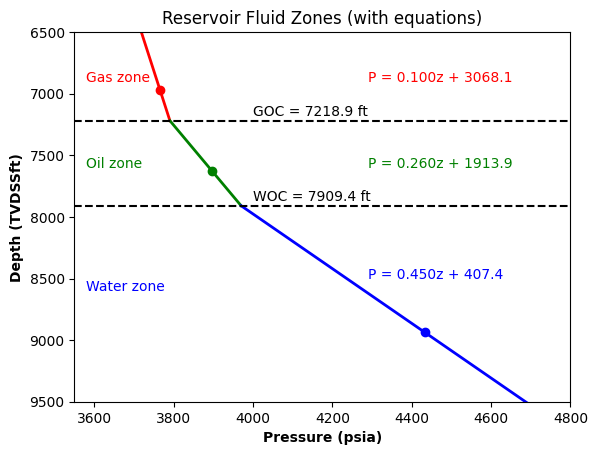

,TVDSS (ft),Formation Pressure (psia),Fluid,Fluid Density (lb/ft³),Fluid Gradient (psi/ft),C_fluid (psia)
0,6967.0,3765.47,Gas,14.4,0.100100,3068.073288
1,7624.0,3896.00,Oil,37.4,0.259982,1913.897621
2,8936.0,4432.64,Water,64.8,0.450450,407.418730


In [6]:
# Reservoir Fluid Zones & Pressure Gradient Example code written by Sukru Merey
# contact: sukrumerey@gmail.com

"""
Reservoir fluid pressure gradients are measured using wireline pressure gauges, allowing engineers to determine 
the depths of the gas–oil contact (GOC) and water–oil contact (WOC). 
The following is an example (from Example on Page 9 of Sanni, M. (2019). Petroleum Engineering. Principles, Calculations and Workflows. Wiley) 
illustrating these measurements and how GOC and WOC depths are calculated.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# GIVEN TEST DATA (INPUT DATA)
# -----------------------------
z_gas, P_gas_pt,rho_gas = 6967.0, 3765.47,14.4 # TVDSS, ft; pressure, psia; fluid density, lb/ft3
z_oil, P_oil_pt,rho_oil = 7624.0, 3896.00,37.4
z_water, P_water_pt,rho_water = 8936.0, 4432.64,64.8


# Pressure Gradients
g_gas = 0.052*rho_gas*0.13368055787372 # psi/ft
g_oil = 0.052*rho_oil*0.13368055787372
g_water = 0.052*rho_water*0.13368055787372

# Intercepts
C_gas = P_gas_pt - g_gas * z_gas
C_oil = P_oil_pt - g_oil * z_oil
C_water = P_water_pt - g_water * z_water

# Contact Depths in TVDSS ft
z_GOC = (C_oil - C_gas) / (g_gas - g_oil) 
z_WOC = (C_water - C_oil) / (g_oil - g_water)

# -----------------------------
# ZONES
# -----------------------------
z_gas_range = np.linspace(6500, z_GOC, 100)
z_oil_range = np.linspace(z_GOC, z_WOC, 100)
z_water_range = np.linspace(z_WOC, 9600, 100)

# Pressures
P_gas = g_gas * z_gas_range + C_gas
P_oil = g_oil * z_oil_range + C_oil
P_water = g_water * z_water_range + C_water

# -----------------------------
# PLOT
# -----------------------------
plt.figure()

plt.plot(P_gas, z_gas_range, 'r', linewidth=2)
plt.plot(P_oil, z_oil_range, 'g', linewidth=2)
plt.plot(P_water, z_water_range, 'b', linewidth=2)

# Points
plt.scatter([P_gas_pt], [z_gas], color='red')
plt.scatter([P_oil_pt], [z_oil], color='green')
plt.scatter([P_water_pt], [z_water], color='blue')

# Contacts
plt.axhline(z_GOC, color='black', linestyle='--')
plt.axhline(z_WOC, color='black', linestyle='--')

# -----------------------------
# FORMULAS ON FIGURE
# -----------------------------
plt.text(4290, 6900, f"P = {g_gas:.3f}z + {C_gas:.1f}", color='red')
plt.text(4290, 7600, f"P = {g_oil:.3f}z + {C_oil:.1f}", color='green')
plt.text(4290, 8500, f"P = {g_water:.3f}z + {C_water:.1f}", color='blue')

plt.text(4000, z_GOC - 40, f"GOC = {z_GOC:.1f} ft", color='black')
plt.text(4000, z_WOC - 40, f"WOC = {z_WOC:.1f} ft", color='black')

# Zone labels
plt.text(3580, 6900, "Gas zone", color='red')
plt.text(3580, 7600, "Oil zone", color='green')
plt.text(3580, 8600, "Water zone", color='blue')

# Axes
plt.gca().invert_yaxis()
plt.xlabel("Pressure (psia)",fontweight='bold')
plt.ylabel("Depth (TVDSSft)",fontweight='bold')
plt.title("Reservoir Fluid Zones (with equations)")

plt.xlim(3550, 4800)
plt.ylim(9500, 6500)

plt.show()

# -----------------------------
# RESULTS
# -----------------------------
data = {
    'TVDSS_ft': [z_gas, z_oil, z_water],
    'Formation_pressure_psia': [P_gas_pt,P_oil_pt,P_water_pt],
    'Fluid': ['Gas', 'Oil', 'Water'],
    'Fluid_density_lb_per_ft3': [rho_gas, rho_oil, rho_water],
    'Fluid_gradient_psi_per_ft': [g_gas,g_oil,g_water],
    'C_fluid_psia': [C_gas, C_oil, C_water]
}

df = pd.DataFrame(data)

# title with units
df.columns = [
    'TVDSS (ft)',
    'Formation Pressure (psia)',
    'Fluid',
    'Fluid Density (lb/ft³)',
    'Fluid Gradient (psi/ft)',
    'C_fluid (psia)'
]

df
